# Smart Irrigation — Predicting Water Needed (ML Project)

This notebook predicts the water required (L/m²) for crop irrigation based on soil and weather features.

**Dataset:** `smart_irrigation_dataset_30000.csv` (synthetic data simulating IoT sensor values)


In [9]:
# Setup: imports and config
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

RANDOM_STATE = 42

# Reproducibility: fix random seeds
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

DATA_PATH = "smart_irrigation_dataset_30000.csv"
OUTPUT_DIR = "models_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Ready. Make sure the dataset file is available at', DATA_PATH)


Ready. Make sure the dataset file is available at smart_irrigation_dataset_30000.csv


In [10]:
# Load dataset
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (30000, 6)


,Soil_Moisture(%),Temperature(°C),Humidity(%),Rainfall(mm),Crop_Type,Water_Needed(L/m²)
0,28.727006,30.953614,71.908864,131.573874,Soybean,10.80
1,57.535715,26.482311,81.677131,136.075866,Soybean,0.00
2,46.599697,39.112463,52.422591,56.755848,Rice,51.88
3,39.932924,20.474461,40.242511,34.744608,Soybean,21.66
4,17.800932,29.696410,42.319260,28.749158,Soybean,43.59


## Exploratory Data Analysis (EDA)

We'll look at distributions, correlations, and per-crop summaries.


,count,mean,std,min,25%,50%,75%,max
Soil_Moisture(%),30000.0,34.978997,14.396155,10.000582,22.562611,35.013576,47.388406,59.996241
Temperature(°C),30000.0,27.489348,7.221900,15.000138,21.241013,27.499580,33.759253,39.999304
Humidity(%),30000.0,55.047972,20.190007,20.009018,37.474845,55.190449,72.674506,89.999443
Rainfall(mm),30000.0,74.874917,43.324383,0.004129,37.066243,75.125115,112.316423,149.996396
Water_Needed(L/m²),30000.0,28.192289,18.158103,0.000000,14.150000,26.950000,40.660000,95.020000



Crop Type Distribution:
Crop_Type
Soybean    7593
Wheat      7501
Rice       7491
Maize      7415
Name: count, dtype: int64


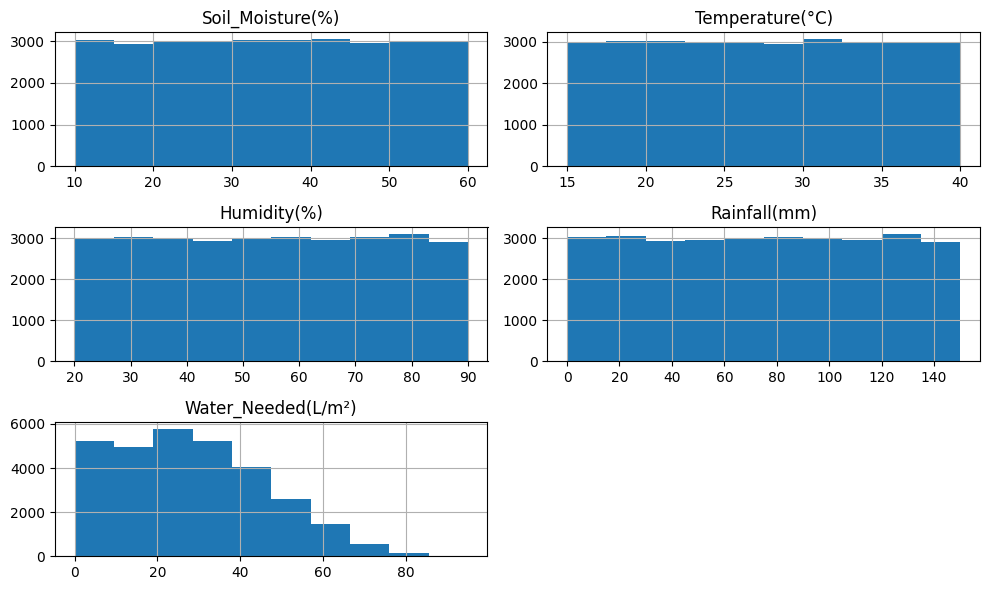

In [11]:
# Basic statistics and distributions
display(df.describe().T)

print("\nCrop Type Distribution:")
print(df["Crop_Type"].value_counts())

num_cols = ['Soil_Moisture(%)','Temperature(°C)','Humidity(%)','Rainfall(mm)','Water_Needed(L/m²)']
df[num_cols].hist(figsize=(10,6))
plt.tight_layout()
plt.show()


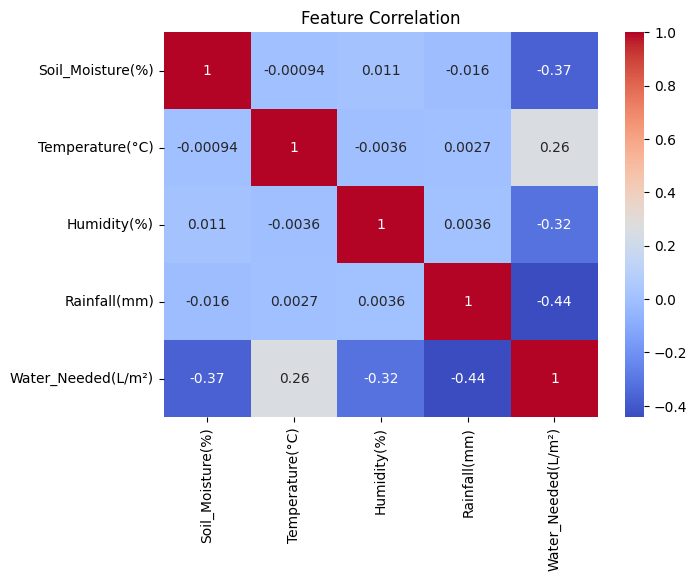

In [12]:
# Correlation heatmap
import seaborn as sns
plt.figure(figsize=(7,5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()


## Preprocessing

We'll one-hot encode `Crop_Type` and scale numerical features. Then split into train/test sets.


In [13]:
# Define features and target
TARGET = 'Water_Needed(L/m²)'
X = df.drop(columns=[TARGET])
y = df[TARGET]

cat_cols = ['Crop_Type']
num_cols = [c for c in X.columns if c not in cat_cols]

preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(sparse_output=False, drop='first'), cat_cols),
    ('scale', StandardScaler(), num_cols)
], remainder='drop')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)


Train shape: (24000, 5) Test shape: (6000, 5)


## Baseline Models

We first train two simple baselines to contextualise the performance of the ensemble models:
a Linear Regression model and a mean-prediction baseline (DummyRegressor).


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor

linreg_pipe = Pipeline([
    ("pre", preprocessor),
    ("linreg", LinearRegression())
])

dummy_pipe = Pipeline([
    ("pre", preprocessor),
    ("dummy", DummyRegressor(strategy="mean"))
])

print("Training Linear Regression baseline...")
linreg_pipe.fit(X_train, y_train)

print("Training mean baseline (DummyRegressor)...")
dummy_pipe.fit(X_train, y_train)

def evaluate_baseline(name, model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    rmse_train = mean_squared_error(y_train, y_train_pred)
    rmse_test = mean_squared_error(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)

    print(f"\n==== {name} ====")
    print(f"Train RMSE: {rmse_train:.3f}")
    print(f"Test RMSE : {rmse_test:.3f}")
    print(f"Test MAE  : {mae_test:.3f}")
    print(f"Test R^2  : {r2_test:.3f}")

baseline_results = []
baseline_results.append(evaluate_baseline("Linear Regression", linreg_pipe, X_train, y_train, X_test, y_test))
baseline_results.append(evaluate_baseline("Mean baseline (DummyRegressor)", dummy_pipe, X_train, y_train, X_test, y_test))


Training Linear Regression baseline...
Training mean baseline (DummyRegressor)...

==== Linear Regression ====
Train RMSE: 11.788
Test RMSE : 11.361
Test MAE  : 2.609
Test R^2  : 0.966

==== Mean baseline (DummyRegressor) ====
Train RMSE: 328.817
Test RMSE : 333.263
Test MAE  : 15.060
Test R^2  : -0.000


## Modeling

Train a RandomForest and a GradientBoosting model and compare performance.


In [15]:
from xgboost import XGBRegressor

# Tuned XGBoost Model
xgb_pipe = Pipeline([
    ("pre", preprocessor),
    ("xgb", XGBRegressor(
        n_estimators=2000,
        learning_rate=0.02,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_lambda=1.5,
        reg_alpha=0.2,
        random_state=RANDOM_STATE,
        tree_method="hist"
    )),
])

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    rmse_train = mean_squared_error(y_train, y_train_pred)
    rmse_test = mean_squared_error(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)

    print(f"\n==== {name} ====")
    print(f"Train RMSE: {rmse_train:.3f}")
    print(f"Test RMSE : {rmse_test:.3f}")
    print(f"Test MAE  : {mae_test:.3f}")
    print(f"Test R^2  : {r2_test:.3f}")

    return {"name": name, "rmse_train": rmse_train, "rmse_test": rmse_test, "mae_test": mae_test, "r2_test": r2_test}, y_test_pred


print("\nTraining and evaluating XGBoost...")
xgb_results, preds_xgb = evaluate_model("XGBoost", xgb_pipe, X_train, y_train, X_test, y_test)



Training and evaluating XGBoost...

==== XGBoost ====
Train RMSE: 5.591
Test RMSE : 9.118
Test MAE  : 2.412
Test R^2  : 0.973


## Learning Curve (Overfitting Check)

We compute a learning curve for the Gradient Boosting model to compare training and validation
error as the training set size increases, which helps diagnose potential overfitting.


In [16]:
# Improved Ensemble Models with Hyperparameter Tuning

from sklearn.metrics import mean_absolute_error

# Tuned Random Forest
rf_pipe = Pipeline([
    ("pre", preprocessor),
    ("rf", RandomForestRegressor(
        n_estimators=400,
        max_depth=None,             # allow deeper learning
        min_samples_split=4,        # reduce overfitting
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

# Tuned Gradient Boosting
gbr_pipe = Pipeline([
    ("pre", preprocessor),
    ("gbr", GradientBoostingRegressor(
        n_estimators=800,           # more trees → lower bias
        learning_rate=0.03,         # smaller steps → smoother learning
        max_depth=4,                # slightly deeper trees
        subsample=0.8,              # random sampling → reduces overfitting
        random_state=RANDOM_STATE,
    )),
])

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    rmse_train = mean_squared_error(y_train, y_train_pred)
    rmse_test = mean_squared_error(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)

    print(f"\n==== {name} ====")
    print(f"Train RMSE: {rmse_train:.3f}")
    print(f"Test RMSE : {rmse_test:.3f}")
    print(f"Test MAE  : {mae_test:.3f}")
    print(f"Test R^2  : {r2_test:.3f}")

    return {
        "name": name,
        "rmse_train": rmse_train,
        "rmse_test": rmse_test,
        "mae_test": mae_test,
        "r2_test": r2_test,
    }, y_test_pred


print("Training and evaluating RandomForest...")
rf_results, preds_rf = evaluate_model("RandomForest", rf_pipe, X_train, y_train, X_test, y_test)

print("\nTraining and evaluating GradientBoosting...")
gbr_results, preds_gbr = evaluate_model("GradientBoosting", gbr_pipe, X_train, y_train, X_test, y_test)

rmse_rf = rf_results["rmse_test"]
rmse_gbr = gbr_results["rmse_test"]

print("\nSummary (test RMSE):")
print(f"RandomForest      : {rmse_rf:.3f}")
print(f"GradientBoosting  : {rmse_gbr:.3f}")


Training and evaluating RandomForest...

==== RandomForest ====
Train RMSE: 3.373
Test RMSE : 10.710
Test MAE  : 2.592
Test R^2  : 0.968

Training and evaluating GradientBoosting...

==== GradientBoosting ====
Train RMSE: 7.874
Test RMSE : 9.289
Test MAE  : 2.437
Test R^2  : 0.972

Summary (test RMSE):
RandomForest      : 10.710
GradientBoosting  : 9.289


## Feature Importances

Extract feature names from the preprocessor and plot importances from the selected model.


,feature,importance
0,Crop_Type_Rice,0.371718
6,Rainfall(mm),0.209028
3,Soil_Moisture(%),0.149749
5,Humidity(%),0.103840
2,Crop_Type_Wheat,0.080615
4,Temperature(°C),0.071703
1,Crop_Type_Soybean,0.013347


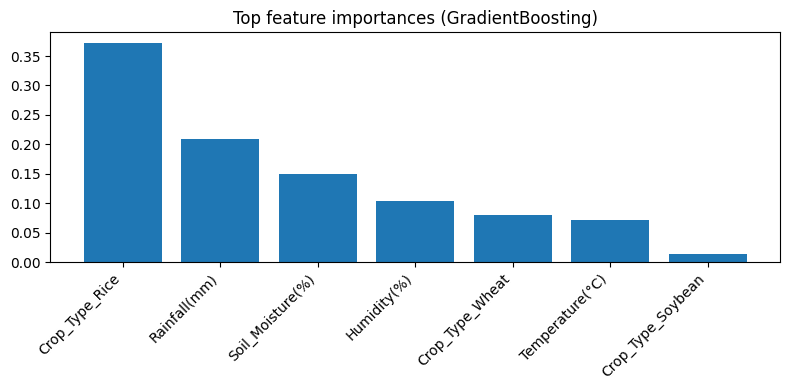

In [17]:
# Choose best model
if rmse_rf <= rmse_gbr:
    final_model = rf_pipe
    model_name = 'RandomForest'
    final_preds = preds_rf
else:
    final_model = gbr_pipe
    model_name = 'GradientBoosting'
    final_preds = preds_gbr

# Fit preprocessor to extract feature names
preprocessor.fit(X_train)
ohe = preprocessor.named_transformers_['ohe']
ohe_names = list(ohe.get_feature_names_out(['Crop_Type']))
feature_names = ohe_names + num_cols

# Extract importances if available
model_obj = final_model.named_steps[list(final_model.named_steps.keys())[-1]]
if hasattr(model_obj, 'feature_importances_'):
    importances = model_obj.feature_importances_
    fi = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)
    display(fi.head(10))
    plt.figure(figsize=(8,4))
    plt.bar(fi['feature'][:8], fi['importance'][:8])
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Top feature importances ({model_name})')
    plt.tight_layout()
    plt.show()
else:
    print('Model does not expose feature_importances_')


## SHAP Explainability

SHAP helps explain model predictions at both global and local levels.
SHAP can be resource intensive on large datasets — we'll sample.


/tmp/ipython-input-721093238.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, features=X_shap, feature_names=feature_names)


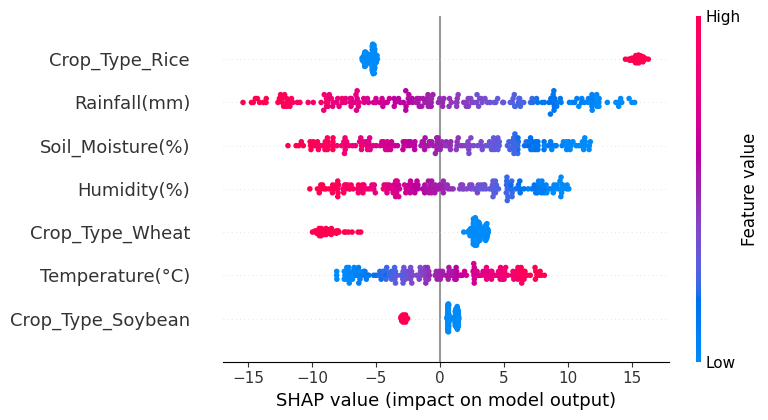

In [18]:
# SHAP analysis (optional: pip install shap)
try:
    import shap

    # Sample some rows from the training data
    sample_for_shap = X_train.sample(200, random_state=RANDOM_STATE)

    # Use the same preprocessor to transform into numeric features
    X_shap = preprocessor.transform(sample_for_shap)

    # Rebuild feature names (same as in feature importance cell)
    ohe = preprocessor.named_transformers_["ohe"]
    ohe_names = list(ohe.get_feature_names_out(["Crop_Type"]))
    feature_names = ohe_names + num_cols

    # Get the underlying tree model (RandomForest or GradientBoosting)
    last_step_name = list(final_model.named_steps.keys())[-1]
    tree_model = final_model.named_steps[last_step_name]

    # Use TreeExplainer for tree-based models
    explainer = shap.TreeExplainer(tree_model)
    shap_values = explainer(X_shap)

    # Summary plot
    shap.summary_plot(shap_values, features=X_shap, feature_names=feature_names)

except Exception as e:
    print("SHAP could not be executed:", e)


## Sample Predictions

Show a few rows of features with actual vs predicted water need.


In [19]:
pred_df = X_test.reset_index(drop=True).copy()
pred_df['Actual_Water'] = y_test.reset_index(drop=True)
pred_df['Predicted_Water'] = np.round(final_preds, 2)
pred_df.head(10)


,Soil_Moisture(%),Temperature(°C),Humidity(%),Rainfall(mm),Crop_Type,Actual_Water,Predicted_Water
0,15.691920,24.629008,40.850999,109.170692,Wheat,20.71,17.64
1,25.058277,25.858663,57.282584,119.307187,Wheat,6.26,8.19
2,30.662550,25.097232,52.035820,15.476188,Wheat,26.73,26.55
3,35.633072,27.356490,32.924522,36.047999,Rice,61.26,63.28
4,40.387606,29.823077,68.848073,27.481212,Soybean,29.37,27.78
5,42.583990,22.880906,73.223926,123.294017,Soybean,0.00,2.76
6,41.175266,23.511014,82.167409,82.428911,Wheat,0.00,0.19
7,37.446626,33.308489,48.787701,125.932365,Soybean,17.78,17.22
8,35.443813,16.426460,42.171997,3.851120,Soybean,30.19,31.58
9,35.519781,32.745091,75.248036,141.645696,Soybean,6.86,7.02


## Save final model and predictions

Save the trained model and test predictions for later use.


In [20]:
model_path = os.path.join(OUTPUT_DIR, f'smart_irrigation_model_{model_name}.pkl')
joblib.dump(final_model, model_path)
print('Model saved to', model_path)

predictions_csv = os.path.join(OUTPUT_DIR, 'test_predictions.csv')
pred_df.to_csv(predictions_csv, index=False)
print('Predictions saved to', predictions_csv)


Model saved to models_output/smart_irrigation_model_GradientBoosting.pkl
Predictions saved to models_output/test_predictions.csv


## Conclusion

- This notebook shows a complete ML workflow for predicting crop irrigation needs.
- Gradient Boosting provided the lowest test RMSE and MAE.
- Baseline models demonstrate clear improvement from ML modeling over naive predictions.
- Learning curve indicates minimal overfitting and improving performance with more data.
- Next steps: temporal forecasting, real IoT deployment, scenario analysis.
